In [87]:
# Import bibliotek
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber, LogCosh

In [3]:
# Funkcje pomocnicze: wykres predykcji modelu, metryki oceny modelu RMSE i MAE)
def plot_predictions(test,predicted):
  plt.plot(test, color='red',label='Real IBM Stock Price')
  plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
  plt.title('IBM Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('IBM Stock Price')
  plt.legend()
  plt.show()

def return_rmse(test, predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("-" * 30)
  print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
  print("-" * 30)

def return_mae(test, predicted):
  mae = mean_absolute_error(test, predicted)
  mape = mean_absolute_percentage_error(test, predicted) * 100
  print("Średni błąd bezwzględny: {:.2f}.".format(mae))
  print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
  print("-" * 30)

In [5]:
# Wczytanie danych
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=[ 'Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [6]:
# Ustawiamy zbiory trenujące i testowe oraz szukamy brakujących wartości
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset ['2017':]. iloc[:,1:2].values

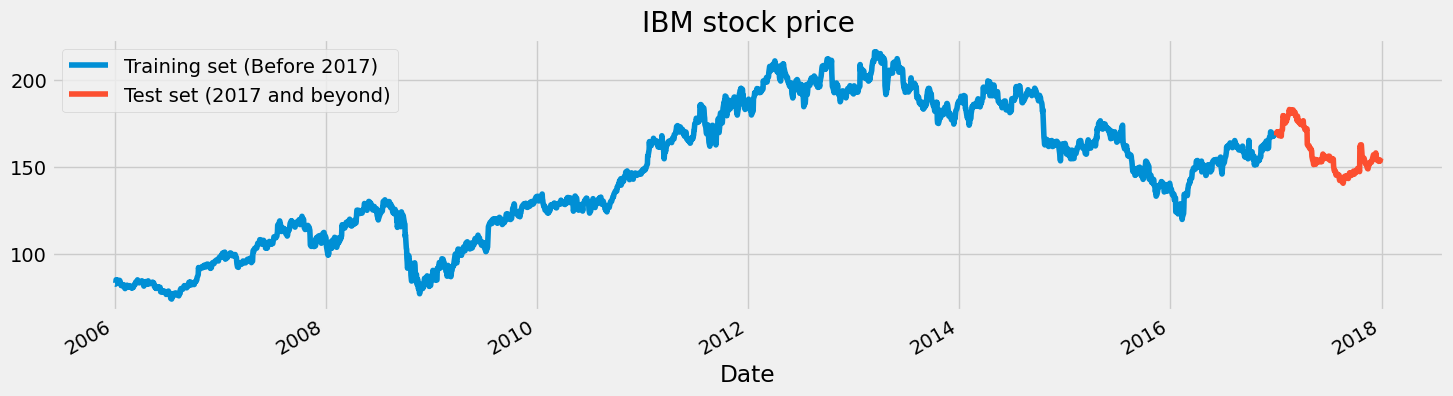

In [114]:
# Wizualizacja danych
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [8]:
# Normalizacja danych trenujących
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [9]:
# Tworzymy strukturę danych z 60 krokami czasowymi i 1 wyjściem
x_train = []
y_train = []
for i in range(60,2769):
  x_train.append(training_set_scaled[i-60:i,0])
  y_train.append(training_set_scaled[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

In [10]:
# Przekształcanie x_train w celu zapewnienia wydajnego modelowania
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

In [120]:
# Architektura LSTM, sieć regresyjna, predykująca
regressor = Sequential()
# Warstwa wejściowa
regressor.add(Input(shape=(x_train.shape[1], 1)))
# Pierwsza warstwa LSTM
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Druga warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Trzecia warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Czwarta warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
# Warstwa wyjściowa
regressor.add(Dense(units=1))

# Ustawaimy funkcję optymalizującą wagi (uczącą) i funkcję straty
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

# Trenujemy sieć, ustawiamy ilość epok i ilość podawanych próbek ze zbioru trenującego
# regressor.fit(x_train, y_train, epochs=50, batch_size=32)

# Wersja treningu z mechanizmem Early Stopping zapobiegającym przeuczeniu się sieci
# (zakomentować powyższe, odkomentować poniższe)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
regressor.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0222 - val_loss: 0.0041
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0106 - val_loss: 0.0015
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0081 - val_loss: 0.0024
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0076 - val_loss: 0.0015
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0068 - val_loss: 0.0018
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0059 - val_loss: 0.0016
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0057 - val_loss: 0.0076


In [121]:
# Teraz przygotujemy zestaw testowy w podobny sposób, jak zestaw treningowy.
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [122]:
# Przygotowanie x_testu i predykcja cen akcji
x_test = []
for i in range(60,311):
  x_test.append(inputs[i-60:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))
predicted_stock_price = regressor.predict(x_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


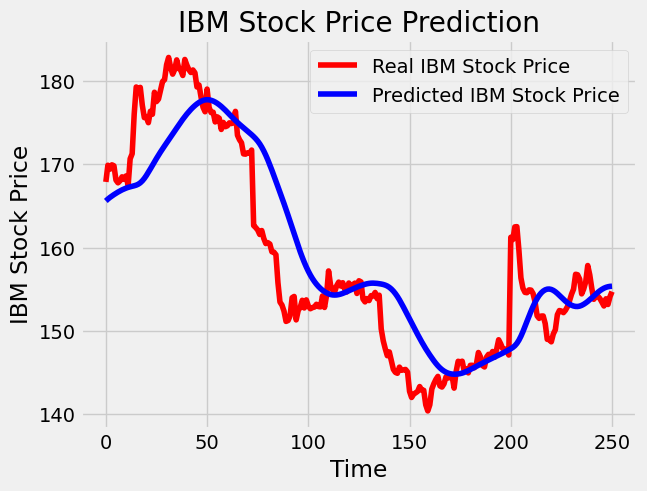

In [123]:
# Wizualizacja wyników dla sieci LSTM
plot_predictions(test_set,predicted_stock_price)

In [124]:
return_rmse(test_set,predicted_stock_price)
return_mae(test_set,predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 5.52.
------------------------------
Średni błąd bezwzględny: 4.12.
Średni błąd bezwzględny procentowy: 2.59%
------------------------------


In [133]:
# Architektura z bramką GRU
regressorGRU = Sequential()
# Warstwa wejściowa
regressorGRU.add (Input(shape=(x_train.shape[1], 1)))
# Pierwsza warstwa GRU z regularyzacją Dropout
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Druga warstwa GRU z regularyzacją Dropout
regressorGRU.add (GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Trzecia warstwa GRU z regularyzacją Dropout
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Czwarta warstwa GRU z regularyzacją Dropout
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Warstwa wyjściowa
regressorGRU.add(Dense(units=1))

# Ustawaimy funkcję optymalizującą wagi (uczącą) i funkcję straty
regressorGRU.compile(optimizer='adam', loss='mean_squared_error')

# Trenujemy sieć, ustawiamy ilość epok i ilość podawanych próbek ze zbioru trenującego
# wersja bez Early Stopping
regressorGRU.fit(x_train, y_train, epochs=50, batch_size=32)

# Wersja treningu z mechanizmem Early Stopping zapobiegającym przeuczeniu się sieci
# (zakomentować powyższe, odkomentować poniższe)
#early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#regressorGRU. fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0147
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0045
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0038
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0033
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0032
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0027
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0028
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0023
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0024
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0023
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0024
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0022
Epoc

In [134]:
# Przygotowanie x_test i przewidywanie cen
x_test = []
for i in range(60,311):
  x_test.append(inputs[i-60:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(x_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


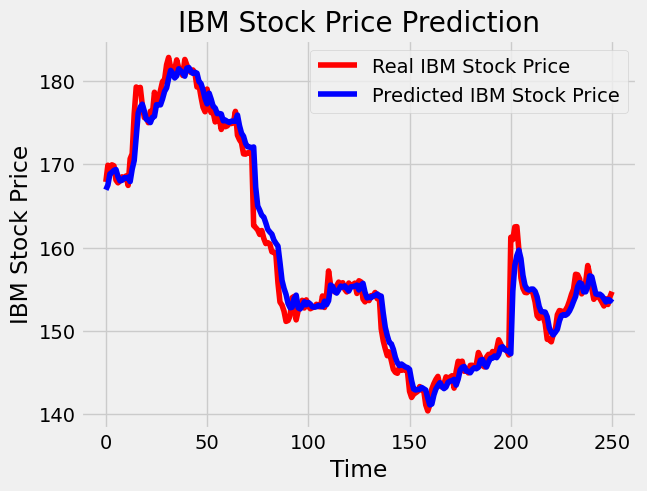

In [135]:
# Wizualizacja wyników dla sieci GRU
plot_predictions(test_set,GRU_predicted_stock_price)

In [136]:
# Ocena modelu
return_rmse(test_set,GRU_predicted_stock_price)
return_mae(test_set,GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 1.90.
------------------------------
Średni błąd bezwzględny: 1.22.
Średni błąd bezwzględny procentowy: 0.77%
------------------------------


W każdym zadaniu domyślnie jest:
- ilość jednostek LSTM / GRU = 50
- optymalizator RMSprop
- funkcja straty Mean Squared Error
- atrybut predykcji "High"
- brak meachnizmu Early Stopping

# Zadanie 1
a) Ilość jednostek LSTM / GRU = 50 (dla każdej warstwy)

LSTM
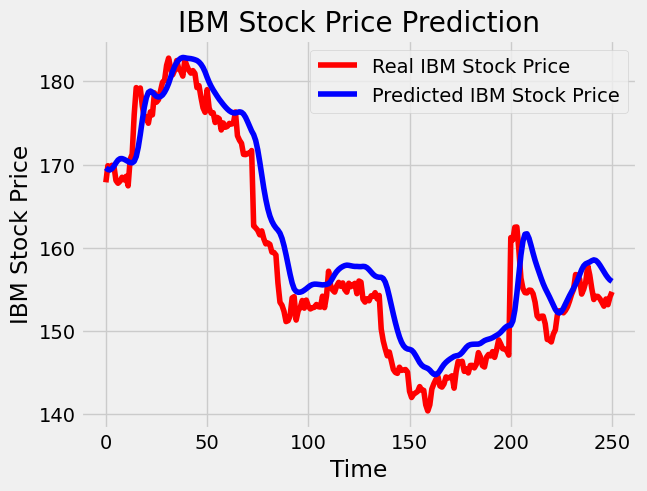

GRU
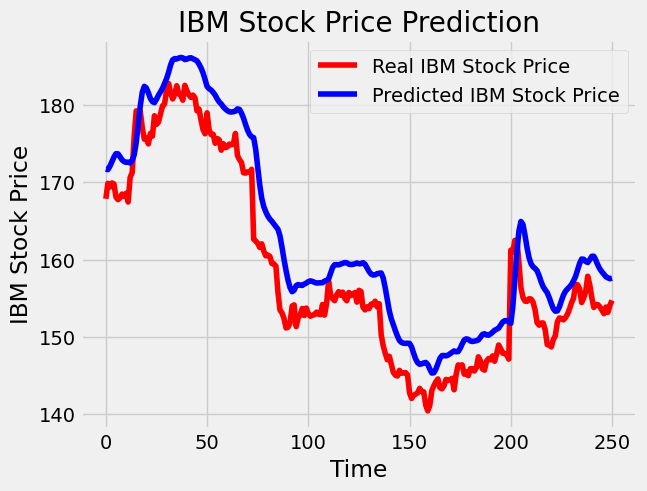

‎
‎

b) Ilość jednostek LSTM / GRU = 10 (dla każdej warstwy)

LSTM
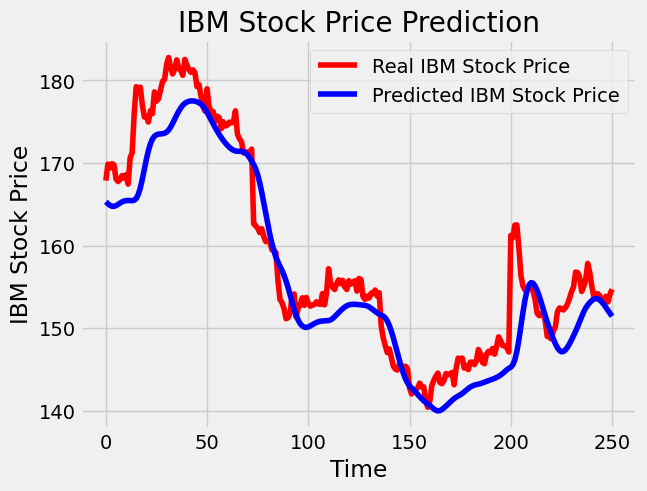

GRU
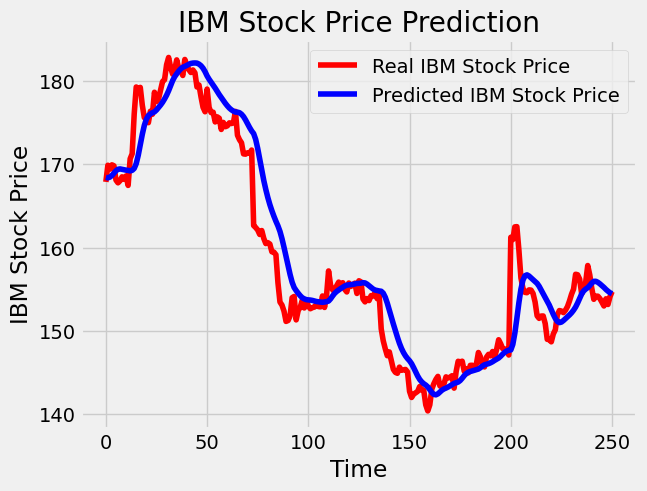

‎
‎

c) Ilość jednostek LSTM / GRU = 100 (dla każdej warstwy)

LSTM
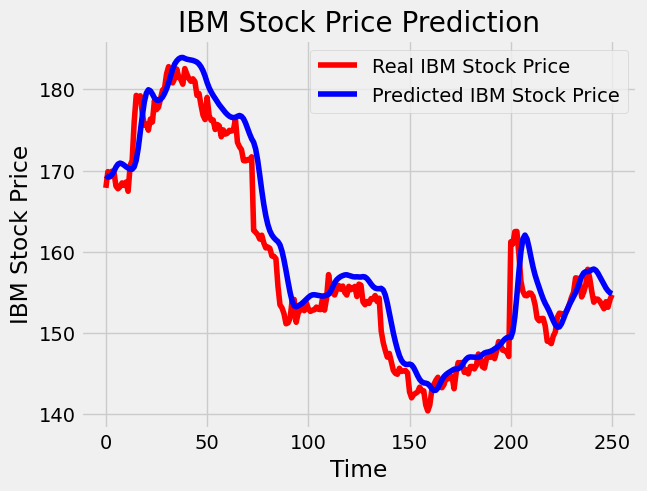

GRU
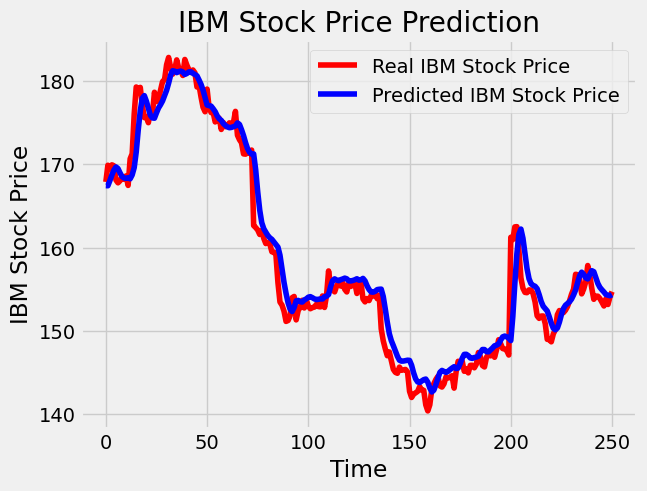

‎
‎

---

‎
‎

# Zadanie 2
a) Optymalizator RMSprop

LSTM
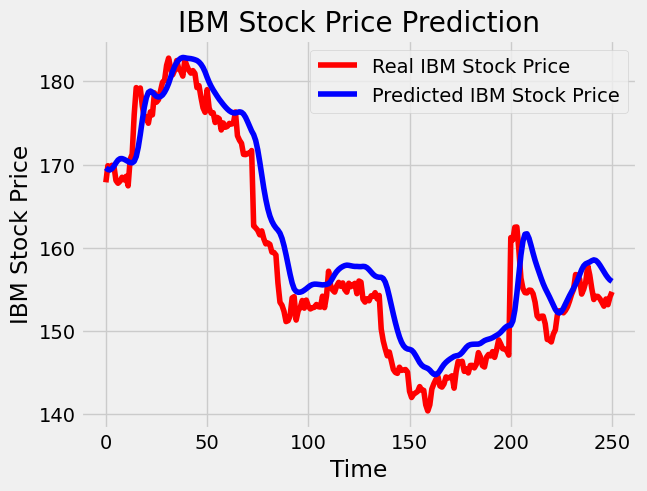

GRU
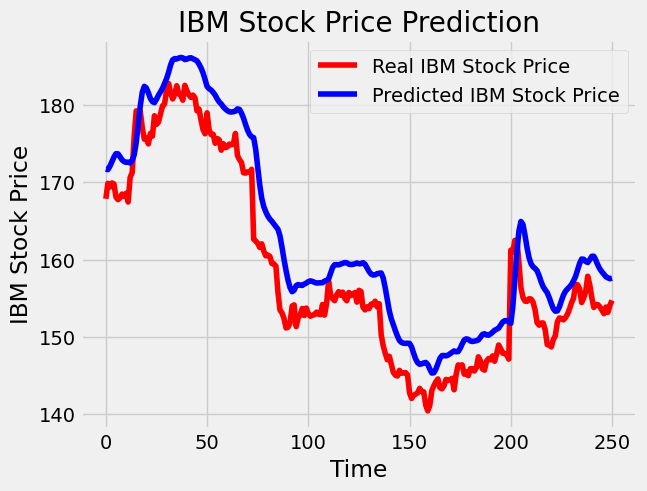

‎
‎

b) Optymalizator SGD

LSTM
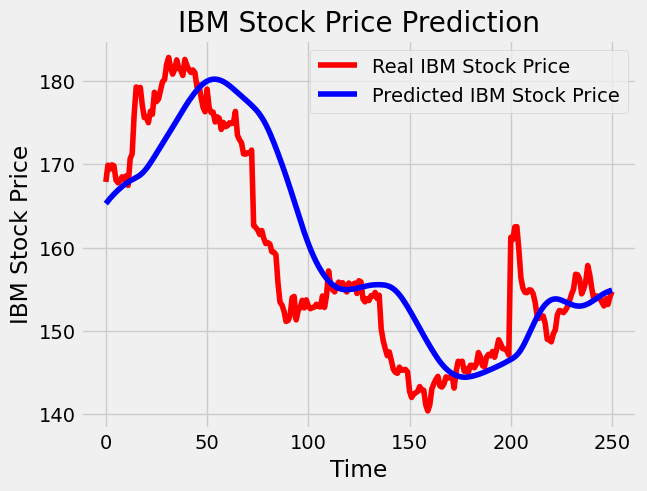

GRU
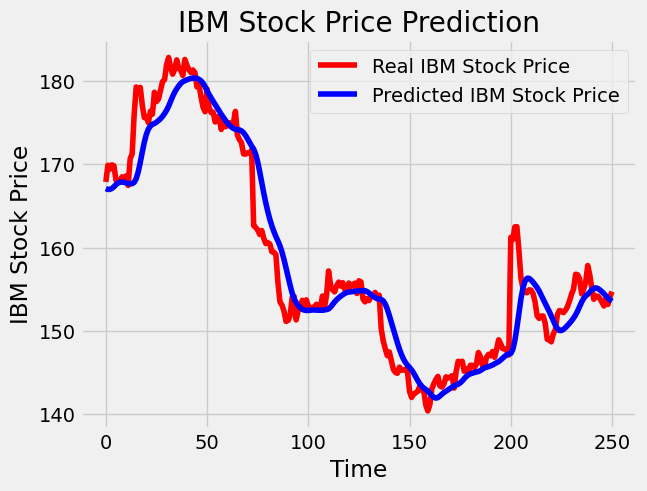

‎
‎

c) Optymalizator Adam

LSTM
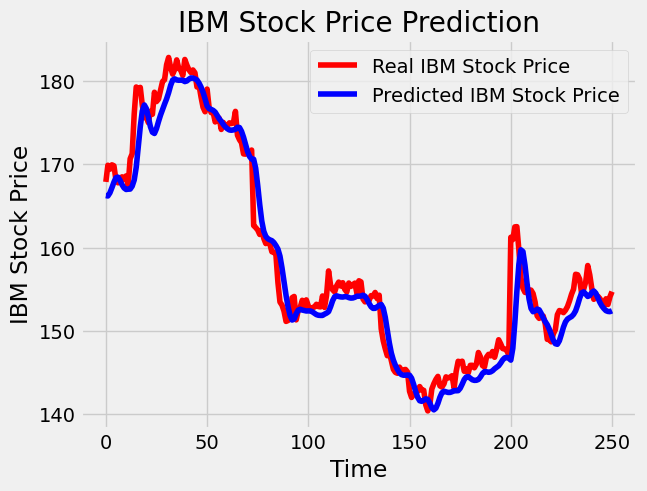

GRU
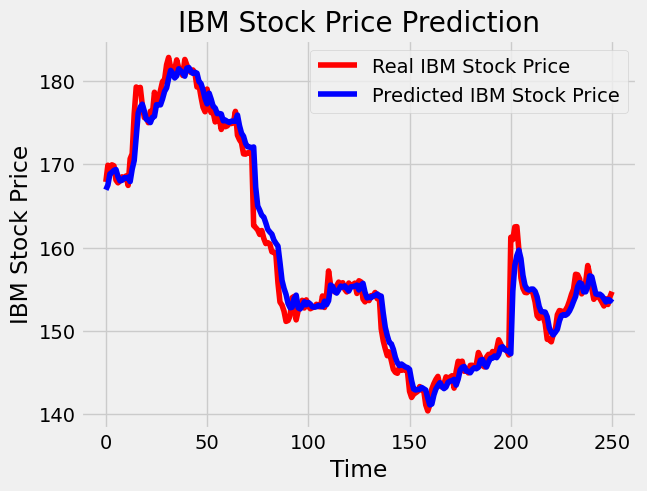

‎
‎

d) Optymalizator AdamW

LSTM
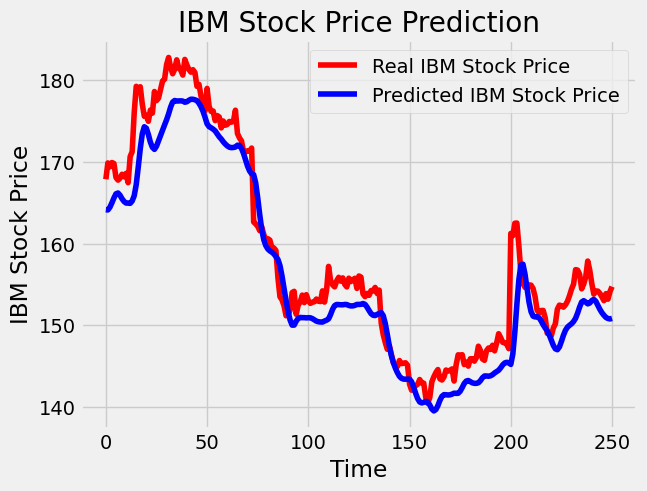

GRU
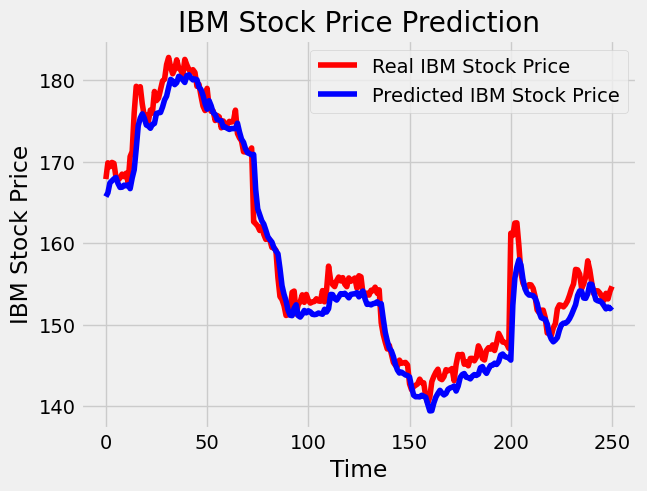

‎
‎

---

‎
‎

# Zadanie 3
a) Funkcja straty Mean Squared Error

LSTM
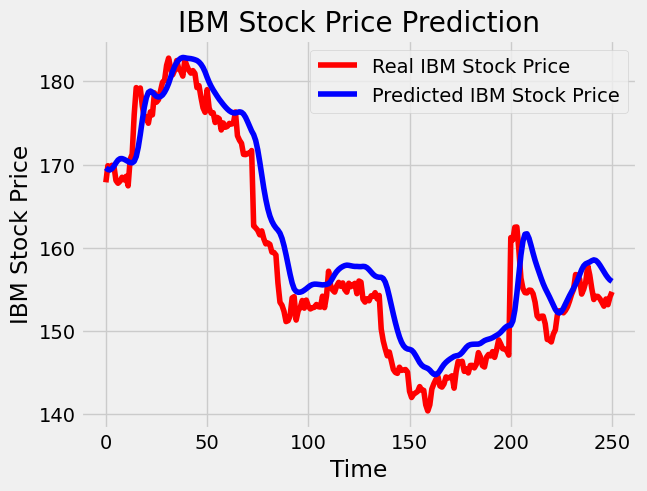

GRU
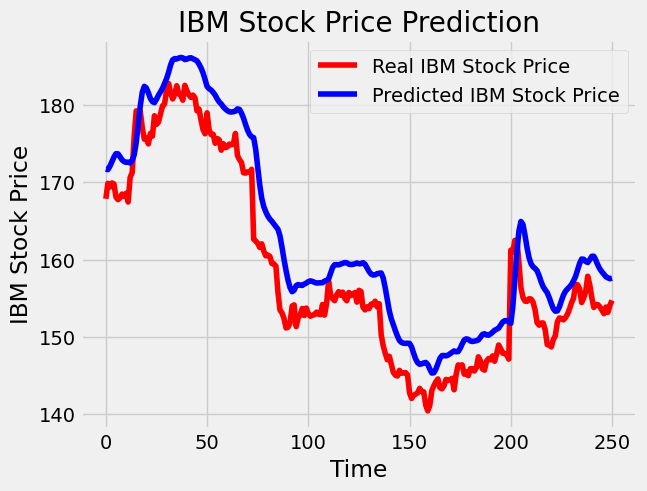

‎
‎

b) Funkcja straty Mean Absolute Error

LSTM
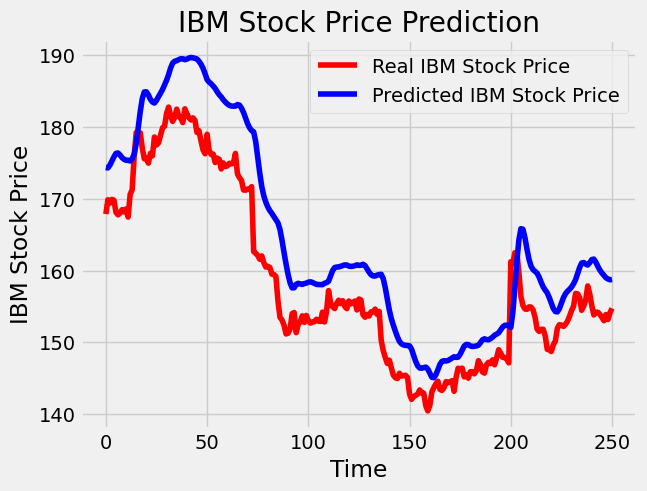

GRU
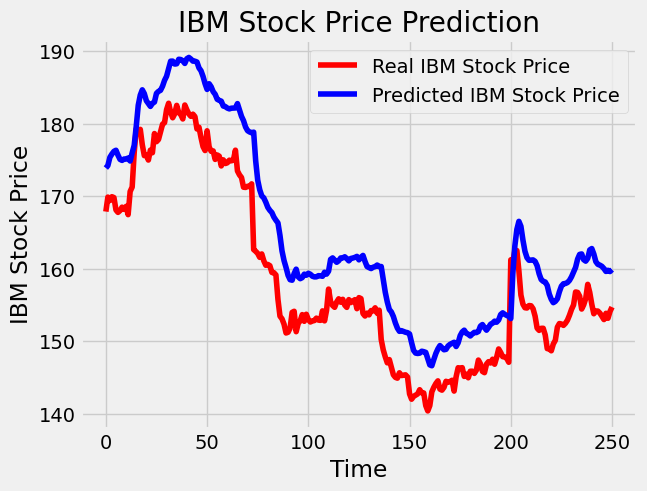

‎
‎

c) Funkcja straty Huber

LSTM
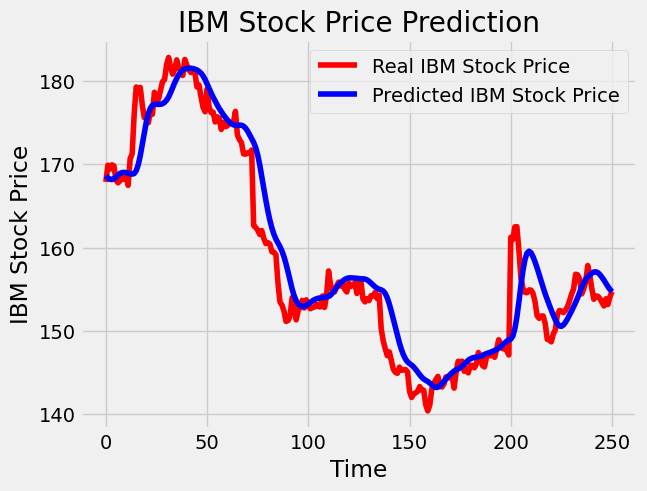

GRU
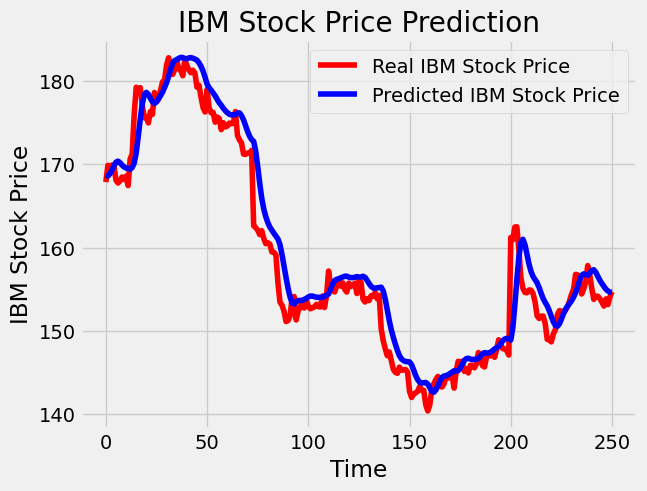

‎
‎

d) Funkcja straty LogCosh

LSTM
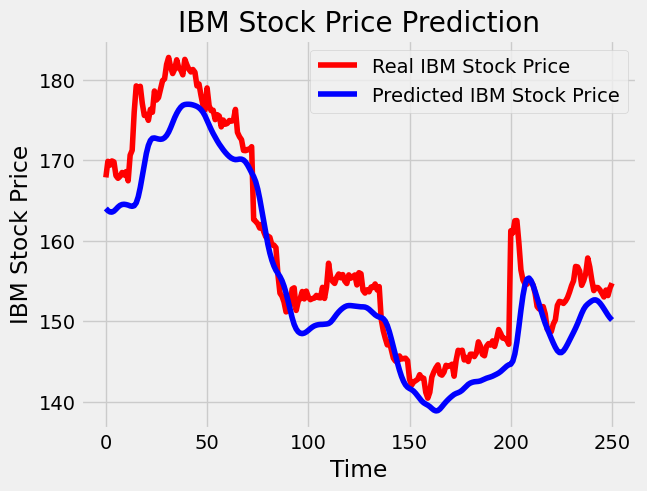

GRU
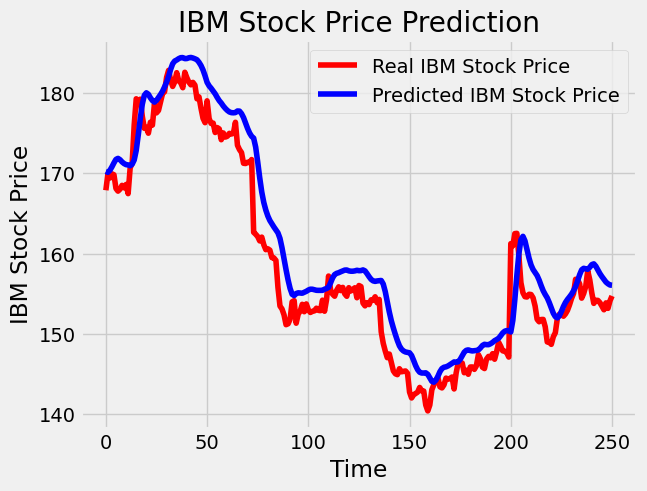

‎
‎

---

‎
‎

# Zadanie 4
a) Atrybut predykcji "High"

LSTM
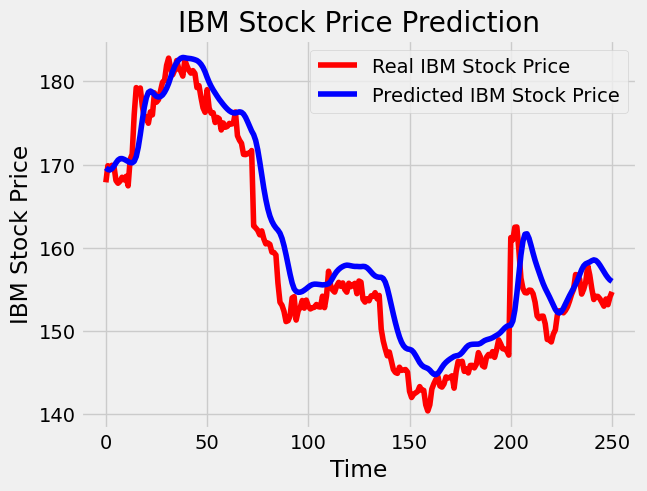

GRU
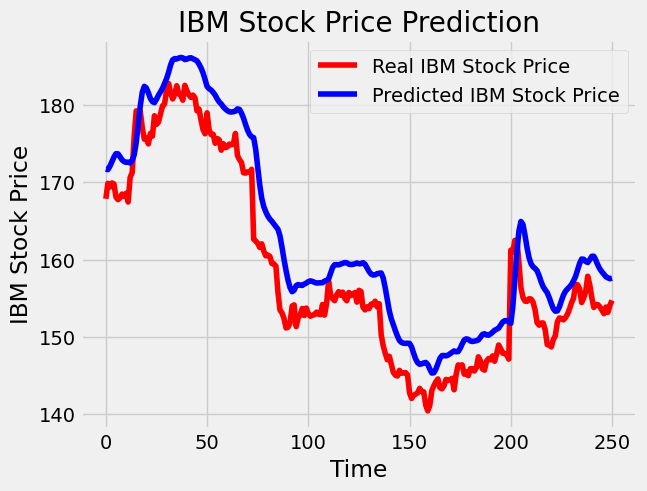

‎
‎

b) Atrybut predykcji "Close"

LSTM
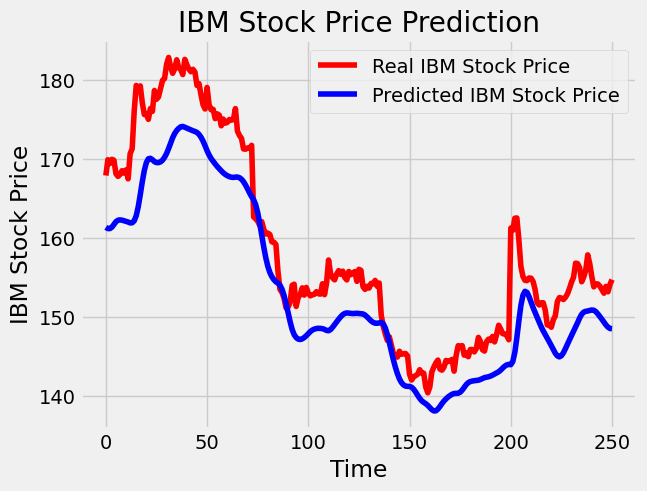

GRU
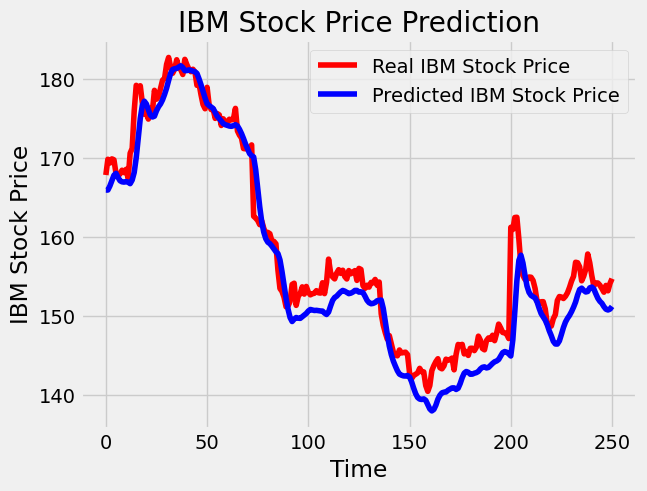

‎
‎

---

‎
‎

# Zadanie 5
a) Brak mechanizmu Early Stopping

LSTM (50/50 epok)
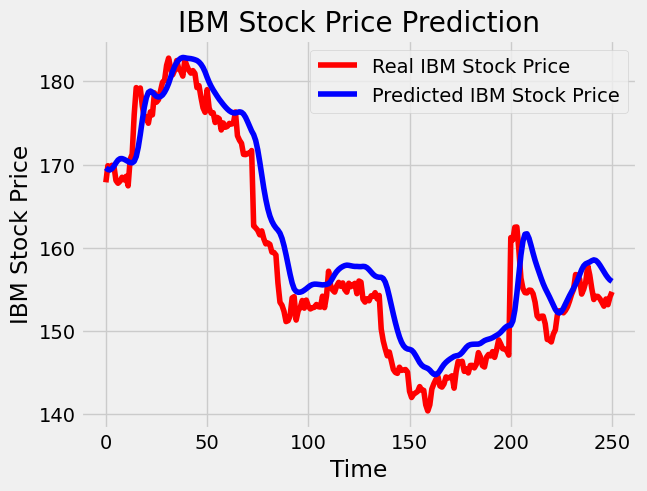

GRU (50/50 epok)
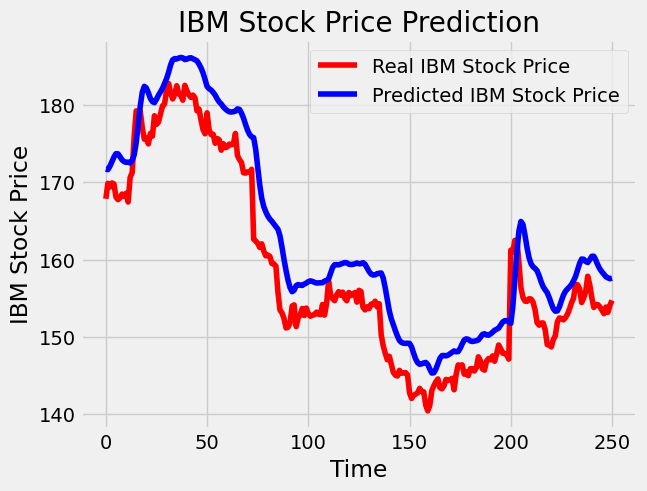

‎
‎

b) Z mechanizmem Early Stopping

LSTM (7/100 epok)
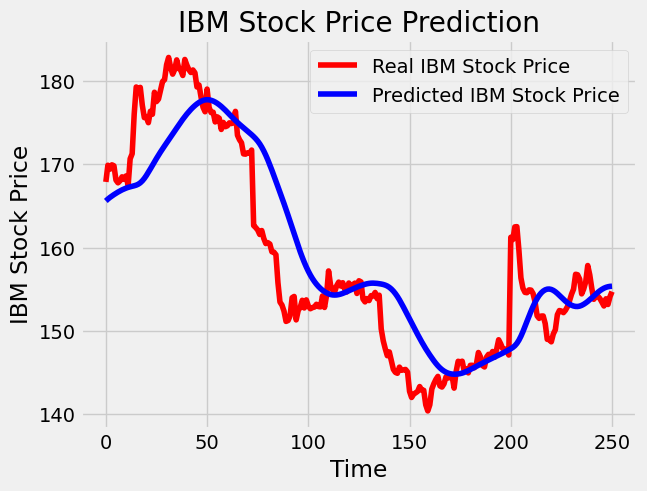

GRU (8/100 epok)
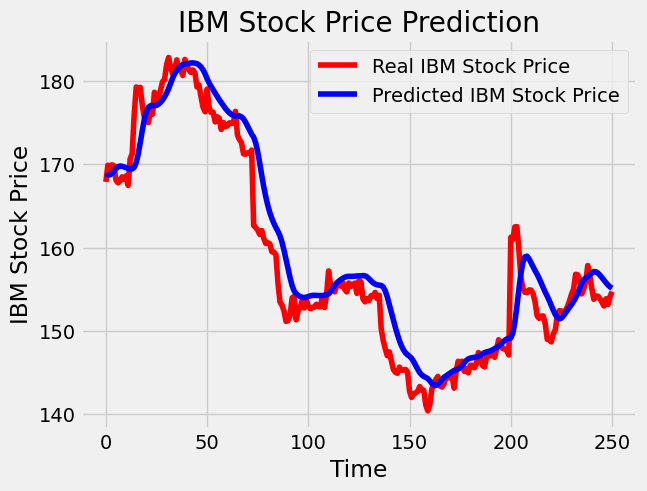

‎
‎

---

‎
‎

# Zadanie 6
Ostateczny błąd RMSE poniżej 2.0 został osiągnięty przy użyciu modelu GRU oraz:
- ilości jednostek GRU = 50
- optymalizatorze Adam
- funkcji straty Mean Squared Error
- atrybucie predykcji "High"
- braku mechanizmu Early Stopping

Wykres
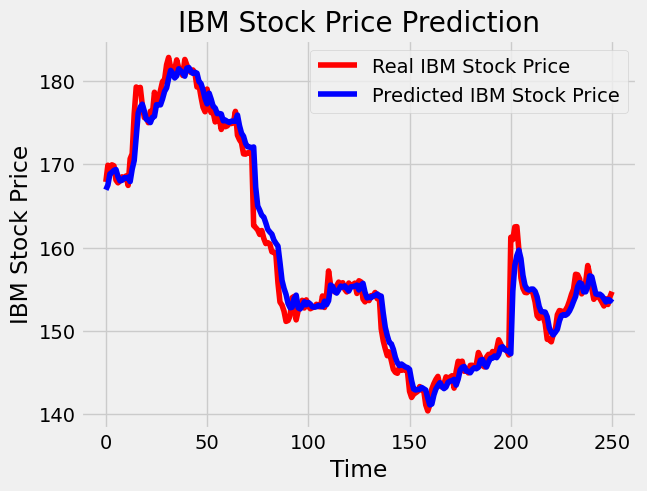

Wynik
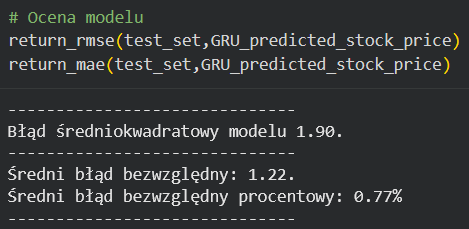

‎
‎

---

‎
‎

# Zadanie 7
